In [58]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [187]:
const Sub_divisions = 32
const count_iterations = 1024
const ω01 = 6.063 * 1000 #MHz
const ωpulse = 6.06 * 1000 #MHz
const precession = 1/(ω01 - ωpulse) # Nanoseconds
const time_to_iter = 2 * Sub_divisions * 1/(precession)
const tolerance = 0.99
const step_size = 5


initial_state = ComplexF64[1;0]
H_Gate = ComplexF64[1/√2 1/√2; 1/√2 -1/√2]
T_gate = ComplexF64[1 0; 0 exp(im*π/Sub_divisions)]
rot_90 = ComplexF64[1/√2 -1/√2; 1/√2 1/√2]

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(t)
    return measure(rot_90 * T_gate ^ t * rot_90 * initial_state)
end

function count(n, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(t)
        if measured == 1
            count += 1
        end
    end
    return count
end

function operate(time)
    iter = time * time_to_iter
    t_range = range(1, iter)
    data = []
    probs = []
    for i in t_range
        push!(data, count(count_iterations, i))
        push!(probs, count(count_iterations, i)/count_iterations)
    end

    Ts = convert_time(range(1, iter))

    return [data, probs, Ts]
end

operate (generic function with 1 method)

In [188]:
function convert_time(lst)
    conv = []
    for i in lst
        push!(conv, i * precession/(2 * Sub_divisions))
    end
    return conv
end

convert_time (generic function with 1 method)

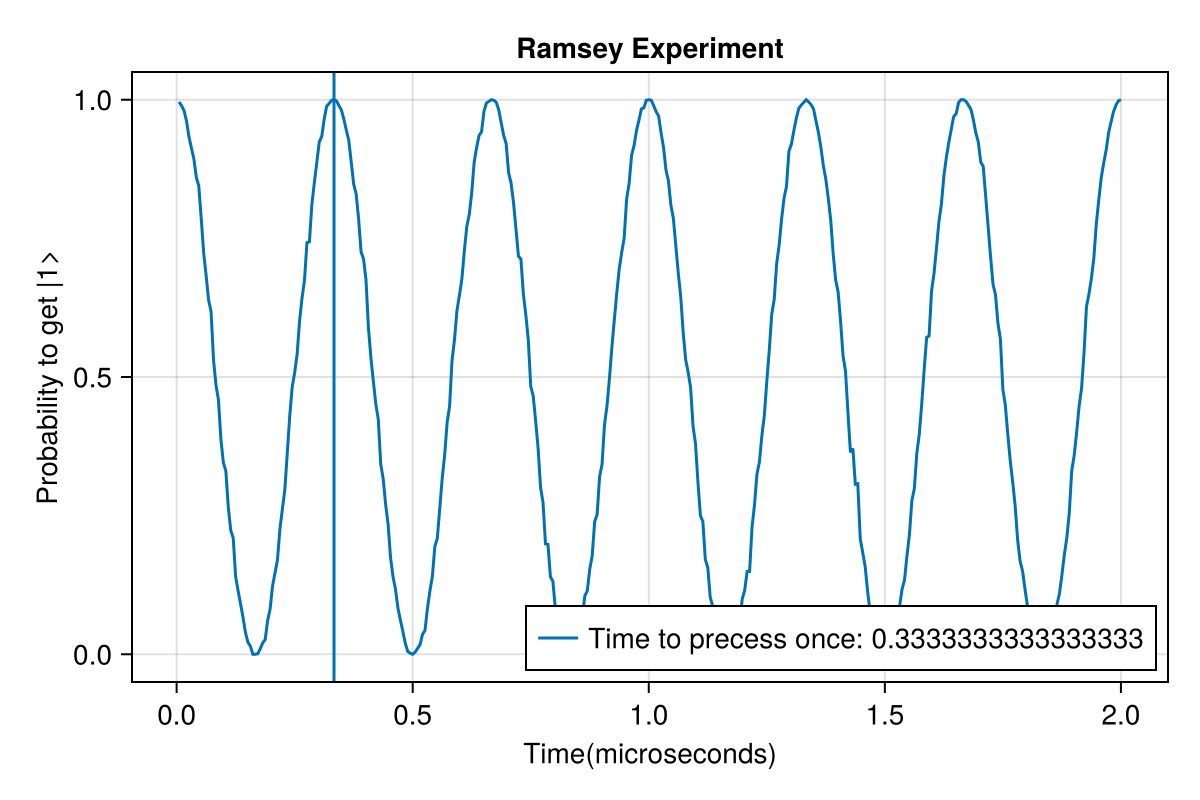

CairoMakie.Screen{IMAGE}


In [209]:
t = 2 # microseconds
g = operate(t)

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
vlines!(ax, precession, label = "Time to precess once: $(precession)")
lines!(ax, g[3], g[2])
axislegend(ax; position = :rb)
display(fig)

In [196]:
function calculate_ramsey_period(lst, tol)
    period = []
    if lst[1]>tol
        push!(period, 1)
    end
    if lst[end]>tol
        push!(period, length(lst))
    end
    for i in range(1,length(lst); step = 5)
        if i > 5  && i < length(lst) - (5+1)
            if lst[i]>tol
                push!(period, i)
            end
        end
    end
    return [period, (period[length(period)] - period[1])/length(period)]
end


function calc_multi_period(time, tol)
    periods = []
    for i in range(1,10)
        push!(periods, calculate_ramsey_period(operate(time)[2], tol)[2])
    end
    return [periods, maximum(periods), sum(periods)/length(periods)]
end


function find_time_periods(time, tol)
    time_period = []
    for i in range(1, 10)
        periods = convert_time(calculate_ramsey_period(operate(time)[2], tol)[1]) 
        for j in range(1, length(periods))
            if periods[j] ∉ time_period
                push!(time_period, periods[j])
            end
        end
    end
    sort!(time_period)
    return time_period
end

function trim_time_periods(time, tol, side_tol)
    time_period_init = find_time_periods(time, tol)
    time_period = copy(time_period_init)
    for i in range(1,length(time_period))
        if i < length(time_period) - 1
            if (time_period[i+1] - time_period[i]) < side_tol
                time_period[i] = (time_period[i+1] + time_period[i])/2
                deleteat!(time_period, i+1) 
            end
        end
    end
    return [time_period_init, time_period]
end

trim_time_periods (generic function with 1 method)

In [197]:
function calc_time_period(time, tol, side_tol)
    peaks =  trim_time_periods(time, tol, side_tol)[2]
    periods = []
    for i in range(1, length(peaks) - 1)
        push!(periods, peaks[i+1] - peaks[i])
    end
    period = sum(periods)/length(periods)
    return [peaks, periods, period, 1/period]
end


calc_time_period (generic function with 1 method)

In [198]:
calc = calc_time_period(20, tolerance, side_dif)

4-element Vector{Any}:
  Any[0.005208333333333333, 0.34375, 0.65625, 0.9947916666666666, 1.3333333333333333, 1.671875, 2.0104166666666665, 2.3229166666666665, 2.661458333333333, 3.0  …  17.010416666666664, 17.322916666666664, 17.661458333333332, 18.0, 18.338541666666664, 18.677083333333332, 18.989583333333332, 19.328125, 19.666666666666664, 20.0]
  Any[0.3385416666666667, 0.3125, 0.33854166666666663, 0.33854166666666663, 0.33854166666666674, 0.3385416666666665, 0.3125, 0.3385416666666665, 0.33854166666666696, 0.3385416666666665  …  0.3385416666666643, 0.3125, 0.33854166666666785, 0.33854166666666785, 0.3385416666666643, 0.33854166666666785, 0.3125, 0.33854166666666785, 0.3385416666666643, 0.3333333333333357]
 0.3332465277777778
 3.0007814535035164

In [201]:
Ts = operate(30)[3]
Δ = calc[4]
A = 0.5
C = 0.5
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000

function P(t, A, C)
    return A * exp(-t/T2x) * cos(2π* Δ * t) + C
end
decaying = []
border = []
for i in Ts
    push!(decaying, P(i, A, C))
    push!(border, A * exp(-i/T2x) + C)
end

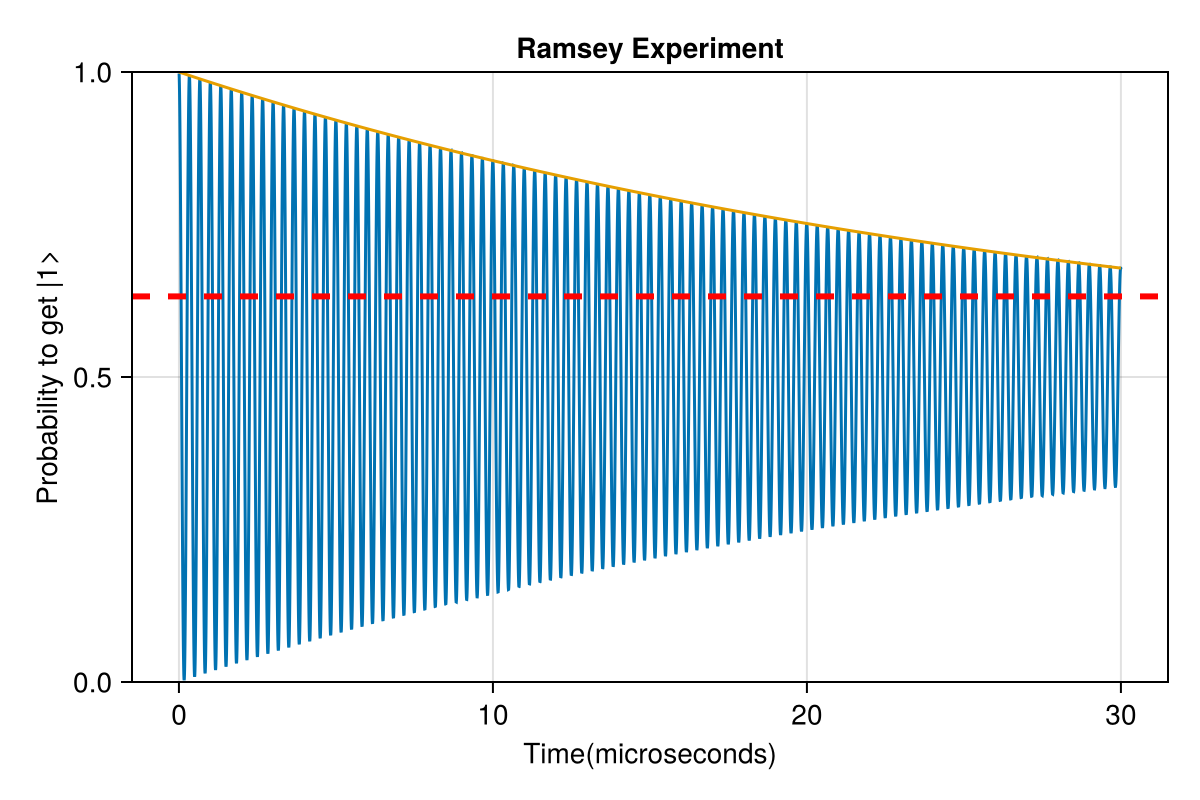

CairoMakie.Screen{IMAGE}


In [213]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, decaying)
lines!(ax, Ts, border)
hlines!(ax, 1-1/ℯ, linewidth = 3, color = :red, linestyle = :dash)
CairoMakie.ylims!(ax, (0.0, 1.0))
display(fig)

In [214]:
save("Ramsey_expirement_decay_t = 30_with_37%.png", fig)